In [5]:
import pandas as pd,numpy as np

### Data Loading And Inspecting

In [6]:
pd.set_option('display.max_columns',None)  


In [7]:
df = pd.read_csv("movies_dataset.csv")  

In [8]:
df.head()

,MovieID,Title,Genre,ReleaseYear,ReleaseDate,Country,BudgetUSD,US_BoxOfficeUSD,Global_BoxOfficeUSD,Opening_Day_SalesUSD,One_Week_SalesUSD,IMDbRating,RottenTomatoesScore,NumVotesIMDb,NumVotesRT,Director,LeadActor
0,1,Might toward capital,Comedy,2003,28-09-03,China,6577427.79,6613685.82,15472035.66,1778530.85,3034053.32,6.2,58,7865,10596,Kristina Moore,Brian Mccormick
1,2,He however experience,Comedy,1988,14-02-88,USA,1883810.10,1930949.15,3637731.12,247115.74,831828.84,5.2,44,1708,220,Benjamin Hudson,Ashley Pena
2,3,Star responsibility politics,Comedy,1971,02-11-71,USA,2468079.29,4186694.69,7165111.24,878453.95,2171405.93,5.5,55,4678,7805,Kayla Young,Alexander Haley
3,4,Exactly live,Comedy,1998,06-08-98,USA,1447311.46,2023683.92,4373820.26,570657.72,898886.01,7.3,87,2467,1751,Michael Ross,Patrick Barnett
4,5,Focus improve especially,Documentary,2021,17-12-21,India,900915.86,2129629.10,3113017.38,361189.37,861775.91,6.1,67,5555,697,Faith Franklin,Duane Fletcher DDS


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 999999 entries, 0 to 999998
Data columns (total 17 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   MovieID               999999 non-null  int64  
 1   Title                 999999 non-null  object 
 2   Genre                 999999 non-null  object 
 3   ReleaseYear           999999 non-null  int64  
 4   ReleaseDate           999999 non-null  object 
 5   Country               999999 non-null  object 
 6   BudgetUSD             999999 non-null  float64
 7   US_BoxOfficeUSD       999999 non-null  float64
 8   Global_BoxOfficeUSD   999999 non-null  float64
 9   Opening_Day_SalesUSD  999999 non-null  float64
 10  One_Week_SalesUSD     999999 non-null  float64
 11  IMDbRating            999999 non-null  float64
 12  RottenTomatoesScore   999999 non-null  int64  
 13  NumVotesIMDb          999999 non-null  int64  
 14  NumVotesRT            999999 non-null  int64  
 15  

In [10]:
df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
MovieID,999999.0,NaN,NaN,NaN,500000.0,288674.990257,1.0,250000.5,500000.0,749999.5,999999.0
Title,999999,9665,With,506,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Genre,999999,8,Drama,250018,NaN,NaN,NaN,NaN,NaN,NaN,NaN
ReleaseYear,999999.0,NaN,NaN,NaN,1998.00122,19.260863,1950.0,1984.0,2001.0,2014.0,2025.0
ReleaseDate,999999,27757,24-04-25,93,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Country,999999,10,USA,714581,NaN,NaN,NaN,NaN,NaN,NaN,NaN
BudgetUSD,999999.0,NaN,NaN,NaN,9802823.551187,22494208.371647,100000.0,1190510.79,3265789.51,9002790.955,300000000.0
US_BoxOfficeUSD,999999.0,NaN,NaN,NaN,14961631.979018,38794034.258596,40025.47,1489805.19,4388875.59,12876058.38,1018197889.0
Global_BoxOfficeUSD,999999.0,NaN,NaN,NaN,27206253.682175,69542938.246286,100000.0,2762369.99,8090223.36,23552451.2,1499496720.0
Opening_Day_SalesUSD,999999.0,NaN,NaN,NaN,2992745.166362,8132438.348603,4050.47,279026.24,838722.12,2510359.545,295751068.2


MovieID                 0.0
Title                   0.0
Genre                   0.0
ReleaseYear             0.0
ReleaseDate             0.0
Country                 0.0
BudgetUSD               0.0
US_BoxOfficeUSD         0.0
Global_BoxOfficeUSD     0.0
Opening_Day_SalesUSD    0.0
One_Week_SalesUSD       0.0
IMDbRating              0.0
RottenTomatoesScore     0.0
NumVotesIMDb            0.0
NumVotesRT              0.0
Director                0.0
LeadActor               0.0
dtype: float64


<Axes: >

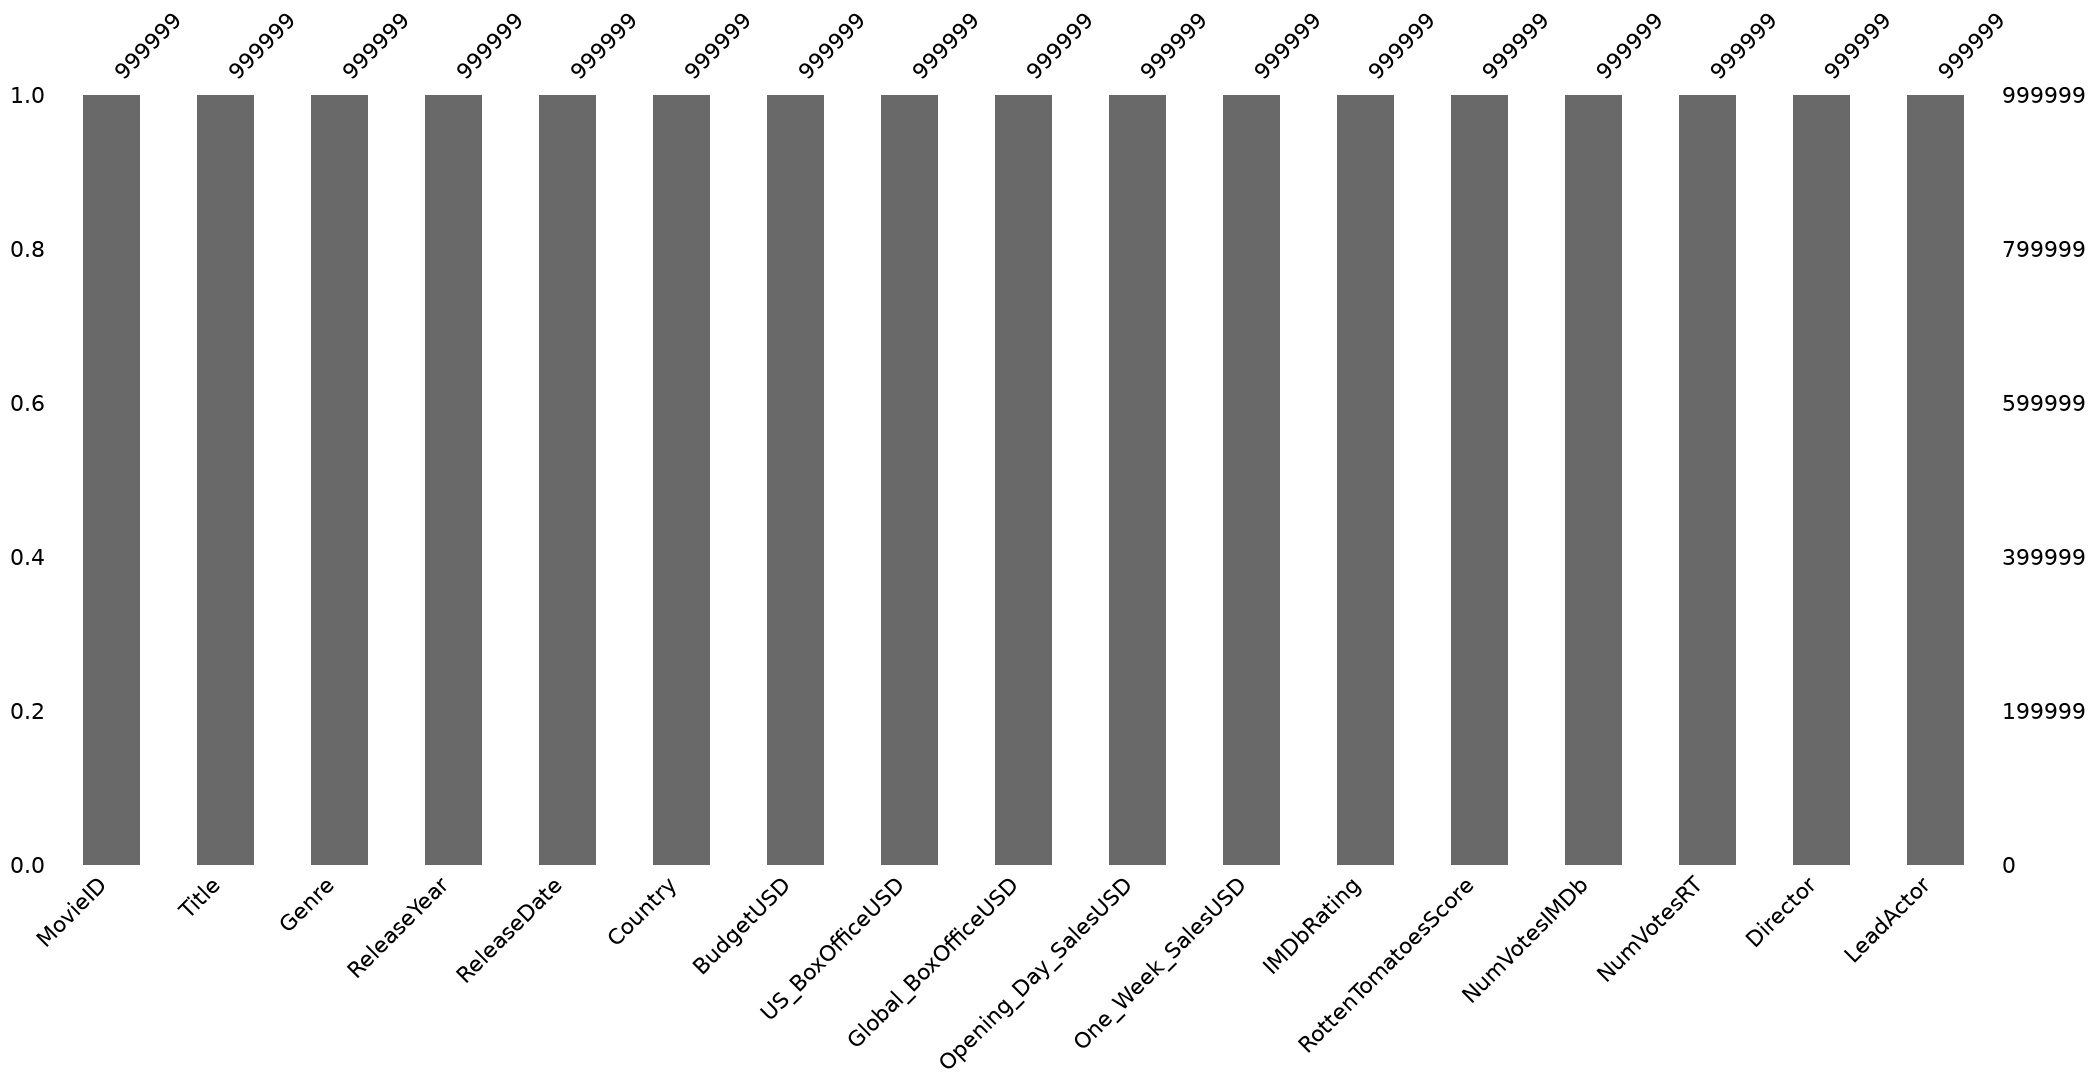

In [11]:
# Percentage of missing values 
missing_pct = round((df.isnull().sum()/len(df))*100,2)
print(missing_pct)

# Columns having missing values (if so) , You can Check in Bar Graph as well
import missingno as msmo
msmo.bar(df)

In [12]:
# Checking Total duplicate
print("Duplicate rows:", df.duplicated().sum())

# Check duplicates based on MovieID (should be unique)
print("Duplicate MovieIDs:", df.duplicated(subset=["MovieID"]).sum()) 



Duplicate rows: 0
Duplicate MovieIDs: 0


#### Dataset Statistics At-a-Glance
* **Total Records:** 999,999 rows | **Total Features:** 17 columns
* **Data Types:** 6 float64, 5 int64, 6 object (All data types verified optimal)
* **Missing Data:** 0 null values detected across all columns
* **Duplicates:** 0 duplicate rows (full uniqueness maintained)

#### Categorical Cardinality Highlights
* **Genre:** 8 total categories (Dominant: Drama)
* **Country:** 10 unique countries (Dominant: USA with ~714k productions)
* **Director:** 150 unique directors (Top: Tara Underwood with 6,898 movies)
* **Lead Actor:** 299 unique actors (Top: Jeffrey Smith with 6,688 movies)

### Data Cleaning

In [13]:
# Fixing ReleasDate 
df['ReleaseDate'] = pd.to_datetime(df['ReleaseDate'], format = '%d-%m-%y', errors= 'coerce')

In [14]:
# Extracting Month and day from Release Date for Analysis
df['ReleaseMonth'] = df['ReleaseDate'].dt.month
df['ReleaseDay'] = df['ReleaseDate'].dt.day_name()

In [15]:
# Standardizing Text Columns
text_col = ['Title','Genre','Country','Director','LeadActor']
for col in text_col:
    df[col] = df[col].str.strip().str.title()
    

In [16]:
# Converting low-Cardinality text to Category type
df['Genre'] = df['Genre'].astype('category')
df['Country'] = df['Country'].astype('category')
print("Genre & Country Columns chaneg to Category type")

Genre & Country Columns chaneg to Category type


In [17]:
# Validate Rating range & flag bad values
imdb_invalid = ( (df['IMDbRating'] < 1) | (df['IMDbRating'] > 10) ) 
Rt_invalid = ( (df['RottenTomatoesScore'] < 0) | (df['RottenTomatoesScore'] > 100) ) 
print(f'[Rating] IMDB out-of-range: {imdb_invalid.sum()} | RottenTomatoes out-of-range: {Rt_invalid.sum()}')

[Rating] IMDB out-of-range: 0 | RottenTomatoes out-of-range: 0


In [18]:
# Outlier Detection (IQR Method) 
money_col = ["BudgetUSD","US_BoxOfficeUSD", "Global_BoxOfficeUSD"]

for col in money_col:
    Q1,Q3 = df[col].quantile(0.25),df[col].quantile(0.75)
    IQR = Q3 - Q1
    outliers = ((df[col] < Q1-1.5*IQR) | (df[col] > Q3+1.5*IQR)).sum()
    print(f'[Outlier] {col}: {outliers} outliers {outliers/len(df)*100:.2f}% - Flagged, not removed')

# Budget outliers → DON'T delete, just flag them
df["IsBlockbuster"] = df["BudgetUSD"] > df["BudgetUSD"].quantile(0.95)

    

[Outlier] BudgetUSD: 109157 outliers 10.92% - Flagged, not removed
[Outlier] US_BoxOfficeUSD: 113724 outliers 11.37% - Flagged, not removed
[Outlier] Global_BoxOfficeUSD: 113298 outliers 11.33% - Flagged, not removed


In [19]:
# Derive new Columns for Analysis

df['ProfitUSD'] = df['Global_BoxOfficeUSD'] - df['BudgetUSD'].round(2)
df['ROI_pct'] = ((df['ProfitUSD'] / df['BudgetUSD'])*100).round(2)
df['OpeningWeekRatio'] = (df['One_Week_SalesUSD'] / df['Global_BoxOfficeUSD']).round(3)
df['Decade'] = (df['ReleaseYear'] // 10*10).astype(str)+'s'
df['AverageScore'] = ((df['IMDbRating']*10 + df['RottenTomatoesScore'])/2).round(2)
df['BudgetTier'] = pd.qcut(df['BudgetUSD'],q=4,labels=['Low','Mid','High','BloackBuster'])

In [20]:
df.head(10)

,MovieID,Title,Genre,ReleaseYear,ReleaseDate,Country,BudgetUSD,US_BoxOfficeUSD,Global_BoxOfficeUSD,Opening_Day_SalesUSD,One_Week_SalesUSD,IMDbRating,RottenTomatoesScore,NumVotesIMDb,NumVotesRT,Director,LeadActor,ReleaseMonth,ReleaseDay,IsBlockbuster,ProfitUSD,ROI_pct,OpeningWeekRatio,Decade,AverageScore,BudgetTier
0,1,Might Toward Capital,Comedy,2003,2003-09-28,China,6577427.79,6613685.82,15472035.66,1778530.85,3034053.32,6.2,58,7865,10596,Kristina Moore,Brian Mccormick,9,Sunday,False,8894607.87,135.23,0.196,2000s,60.0,High
1,2,He However Experience,Comedy,1988,1988-02-14,Usa,1883810.10,1930949.15,3637731.12,247115.74,831828.84,5.2,44,1708,220,Benjamin Hudson,Ashley Pena,2,Sunday,False,1753921.02,93.10,0.229,1980s,48.0,Mid
2,3,Star Responsibility Politics,Comedy,1971,1971-11-02,Usa,2468079.29,4186694.69,7165111.24,878453.95,2171405.93,5.5,55,4678,7805,Kayla Young,Alexander Haley,11,Tuesday,False,4697031.95,190.31,0.303,1970s,55.0,Mid
3,4,Exactly Live,Comedy,1998,1998-08-06,Usa,1447311.46,2023683.92,4373820.26,570657.72,898886.01,7.3,87,2467,1751,Michael Ross,Patrick Barnett,8,Thursday,False,2926508.80,202.20,0.206,1990s,80.0,Mid
4,5,Focus Improve Especially,Documentary,2021,2021-12-17,India,900915.86,2129629.10,3113017.38,361189.37,861775.91,6.1,67,5555,697,Faith Franklin,Duane Fletcher Dds,12,Friday,False,2212101.52,245.54,0.277,2020s,64.0,Low
5,6,Deal Reveal Fine,Drama,1996,1996-05-09,Usa,6356058.11,6790420.62,12332192.70,1877251.88,3681524.22,8.9,100,362,229,Thomas Peterson,Carolyn Calhoun,5,Thursday,False,5976134.59,94.02,0.299,1990s,94.5,High
6,7,Drug When,Comedy,1991,1991-09-24,Usa,30881640.04,35569499.73,61633322.70,5771559.63,21305870.04,3.6,39,556,98,Maria Lane,Melissa Cain,9,Tuesday,False,30751682.66,99.58,0.346,1990s,37.5,BloackBuster
7,8,Almost Option Of,Horror,1990,1990-08-04,Usa,5249748.92,3569563.24,6059156.85,429972.59,1513066.66,7.3,75,283,1219,Diane Skinner,Catherine Willis,8,Saturday,False,809407.93,15.42,0.250,1990s,74.0,High
8,9,Film About Training,Drama,1983,1983-03-12,Usa,4746218.15,6361493.82,9506139.90,1612321.12,2977114.88,6.9,69,1041,1467,Albert Phillips,Ashley Reeves,3,Saturday,False,4759921.75,100.29,0.313,1980s,69.0,High
9,10,Begin Difficult World,Documentary,2005,2005-09-06,Usa,1354686.21,3837061.91,6747065.42,440667.37,2031776.94,8.4,87,10079,514,Francisco Ford,Richard Miller,9,Tuesday,False,5392379.21,398.05,0.301,2000s,85.5,Mid


In [21]:
df.to_csv('D:\DA_Project\Movie Analysis\cleaned_movie_dataset.csv',index = False)
print('Saved -> cleaned_movie_dataset.csv')

<>:1: SyntaxWarning: invalid escape sequence '\D'
<>:1: SyntaxWarning: invalid escape sequence '\D'
C:\Users\hp\AppData\Local\Temp\ipykernel_40812\3294007348.py:1: SyntaxWarning: invalid escape sequence '\D'
  df.to_csv('D:\DA_Project\Movie Analysis\cleaned_movie_dataset.csv',index = False)


Saved -> cleaned_movie_dataset.csv


#### Data Cleaning Summary
* **Audit Finding:**
  * ReleaseDate stored as string - needed Type Conversion.
  * Text Columns has inconsitent casting - needed to be standardization.
  * ~11% outliers in money columns - flagged , not removed.

* **Action Taken:**
    * Converted ReleaseDate from string to proper datetime format.
    * Extracted ReleaseMonth and ReleaseDay from fixed date for time analysis.
    * Applied ".strip(), title()" to Text columns to remove whitespaces and fix casting.
    * Converted Genre and Country column to Category type for saving memory from 1M rows.
    * Created new column "IsBlockBuster" for top 5% budget movies

* **Derived Columns:**
    * ProfitUSD - Actual profit after budget
    * ROI_pct - Return on Investment, normalizing profit across budget
    * OpeningWeekRatio - Revenue generated from 1st week compared to Global Revenue.
    * Decade - Grouping release year
    * AverageScore - Combining IMDb and RT score , for single score
    * BudgetTier - 4-level grouping based on budget (Low| Mid| High| BlockBuster)
    * IsBlockBuster - Flagged top 5% budget films